# M9.1B — Frozen GAP fusion + Fourier vs pooled overlay

Plan: [`plans/milestone_09/09_camera_view_fusion_plan.md`](../../plans/milestone_09/09_camera_view_fusion_plan.md).  
**Canonical narrative:** Final Report **M9 Step 1**. This notebook is the **pooled packing ladder** and the combined Fourier-vs-GAP figure.

**Conclusion:** Fourier's frozen-encoder advantage shrinks as fusion complexity grows; DeepSets can partly compensate for GAP.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")


ROOT=.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from tomography_ml_validation.milestone_09 import describe_paths, m9_corpus_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
READ_CHECKPOINTS = True
cfg_paths = m9_corpus_paths(ROOT, data_mode=DATA_MODE, read_checkpoints=READ_CHECKPOINTS)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(cfg_paths))
print(f"results_dir={display_path(cfg_paths['results_dir'])}")
print(
    f"epochs={cfg_paths['num_epochs']}  stride={cfg_paths['angle_stride_deg']}  "
    f"load_existing={cfg_paths['load_existing']}"
)


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache
results_dir=checkpoints/m9
epochs=200  stride=60.0  load_existing=True


In [3]:
from IPython.display import display

from tomography_ml import get_device
from tomography_ml.studies import DEFAULT_LR_STAGE_B, DEFAULT_LR_STAGE_B_GRID
from tomography_ml_validation.milestone_09 import M9FusionConfig, run_m9_frozen_fusion_family
from tomography_ml_validation.plotting import (
    plot_m9_lr_study,
    plot_m9_param_counts_fourier_vs_pooled,
    plot_m9_rmse_fourier_vs_pooled,
    plot_m9_rmse_ladder,
)

device = get_device()
print(f"device={device}")


device=mps


## Pooled family, then overlay 09_1A artifacts from the same results dir


M9 pooled: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.001  RUN_LR_STUDY=True  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_frozen_pooled_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_frozen_pooled_fusion.pt (10 comparison rows)


,variant_id,display_label,fusion_pattern,packing,backbone_kind,n_views,split,encoder_frozen,lr_stage_b,lr_selection,RMSE_total,RMSE_X,RMSE_Y,RMSE_Z,learned_parameter_count
0,f1b_single_view_pooled_reference,SV pooled,single_view_pooled_reference,NaN,pooled,1,test,False,NaN,NaN,1.450475,1.629874,1.523957,1.154428,32003
1,f1b_shared_xyz_mean_pooled_control,xyz mean pooled,shared_xyz_mean,xyz_mean,pooled,6,test,True,NaN,NaN,1.513919,1.878909,1.554530,0.963839,32003
2,m09_1_compact_fusion_mlp_mean_pool_frozen_pooled,mean-pool MLP pooled,compact_fusion_mlp_mean_pool_frozen_pooled,mean_pool,pooled,6,test,True,0.003,fixed_lr,1.171650,1.541715,1.026173,0.829685,16899
3,m09_1_deepsets_no_fourier,DeepSets no-Fourier,deepsets_no_fourier,deepsets_no_fourier,pooled,6,test,True,0.003,fixed_lr,1.099678,1.446943,0.900844,0.850123,33411
4,m09_1_compact_fusion_mlp_frozen_pooled,ordered concat pooled,compact_fusion_mlp_frozen_pooled,ordered_concat,pooled,6,test,True,0.003,fixed_lr,1.009766,1.253595,0.813519,0.908607,98819
5,f1b_single_view_pooled_reference,SV pooled,single_view_pooled_reference,NaN,pooled,1,validation,False,NaN,NaN,2.194642,2.662940,2.073547,1.748860,32003
6,f1b_shared_xyz_mean_pooled_control,xyz mean pooled,shared_xyz_mean,xyz_mean,pooled,6,validation,True,NaN,NaN,1.867290,2.549202,1.418674,1.396157,32003
7,m09_1_compact_fusion_mlp_mean_pool_frozen_pooled,mean-pool MLP pooled,compact_fusion_mlp_mean_pool_frozen_pooled,mean_pool,pooled,6,validation,True,0.003,fixed_lr,1.571360,2.267908,0.962830,1.156316,16899
8,m09_1_deepsets_no_fourier,DeepSets no-Fourier,deepsets_no_fourier,deepsets_no_fourier,pooled,6,validation,True,0.003,fixed_lr,1.463432,2.144229,0.916739,0.993363,33411
9,m09_1_compact_fusion_mlp_frozen_pooled,ordered concat pooled,compact_fusion_mlp_frozen_pooled,ordered_concat,pooled,6,validation,True,0.003,fixed_lr,1.309206,1.806509,0.889561,1.042720,98819


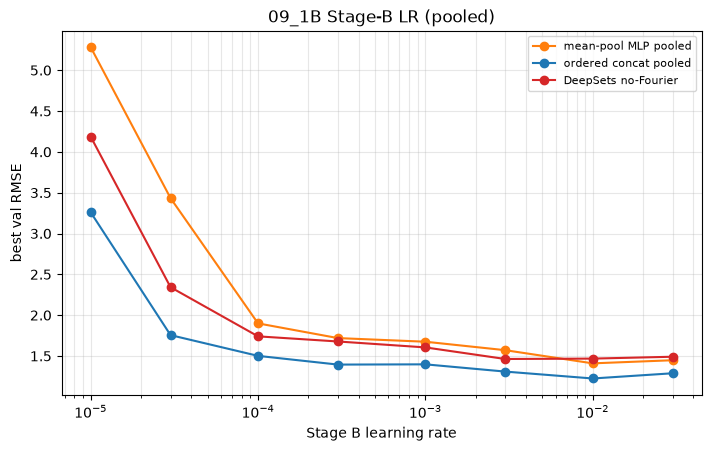

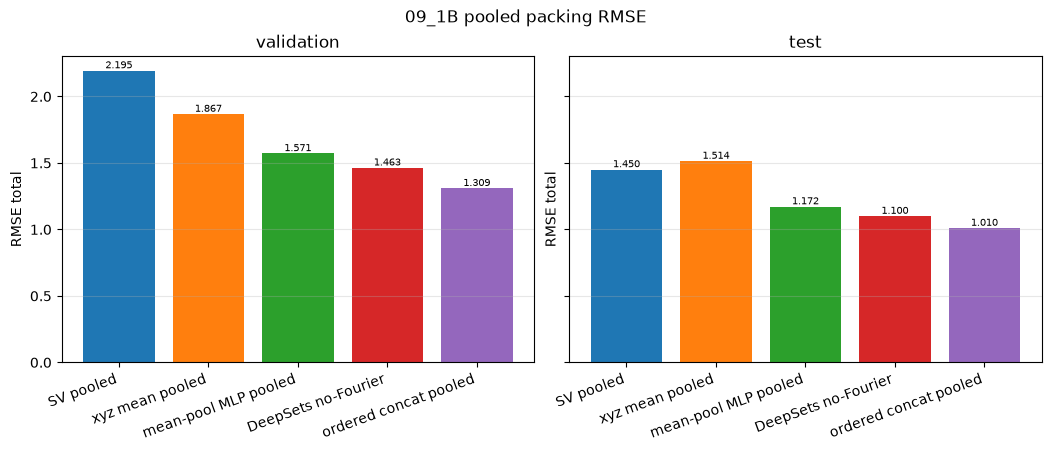

M9 fourier: views=(0.0, 60.0, 120.0, 180.0, 240.0, 300.0)  epochs=200  patience=40  batch=16  lr_stage_a=0.03  RUN_LR_STUDY=False  SKIP_TRAIN=True
Loaded Stage A from checkpoints/m9/m09_frozen_fourier_fusion.pt
SKIP_TRAIN: loaded checkpoints/m9/m09_frozen_fourier_fusion.pt (10 comparison rows)


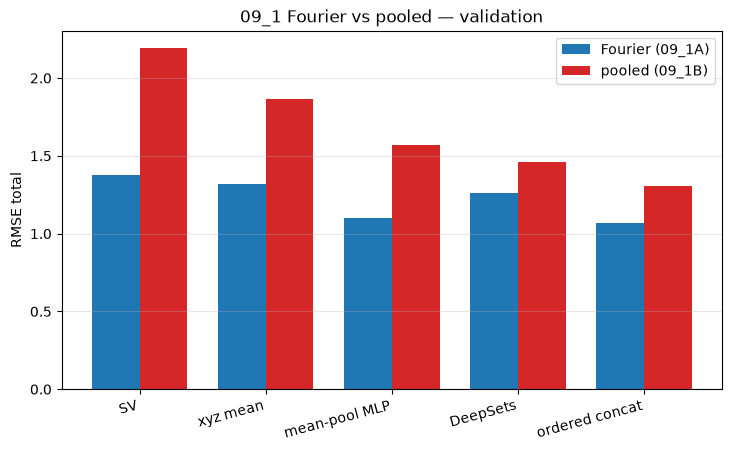

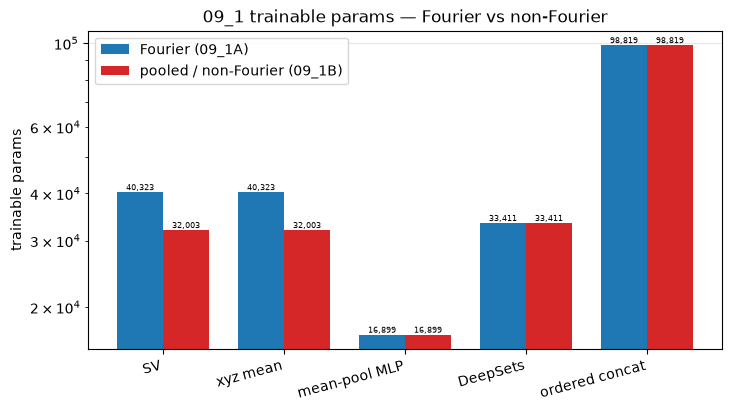

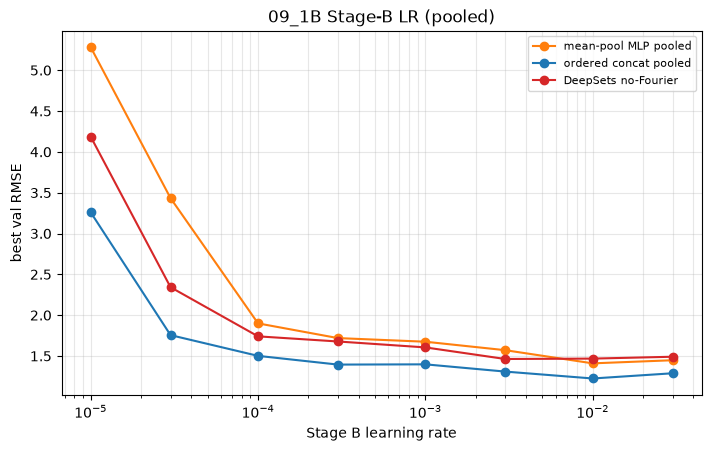

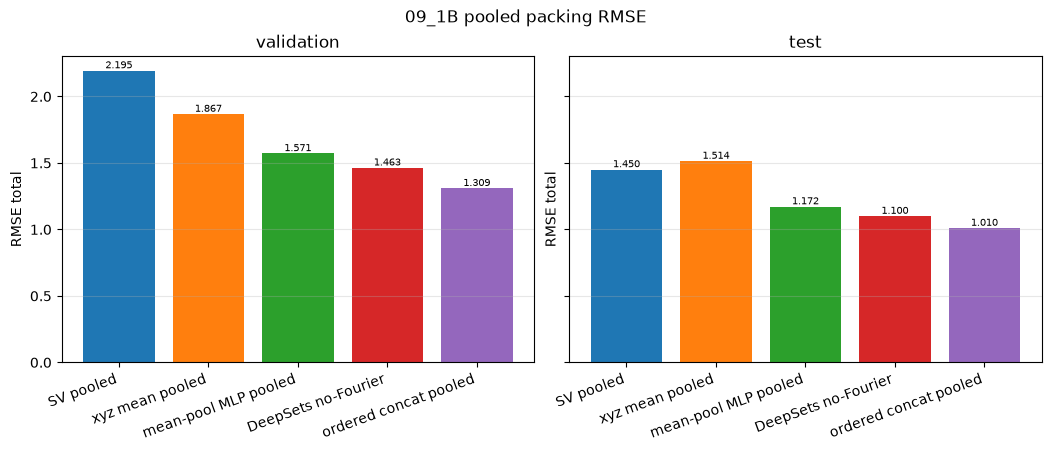

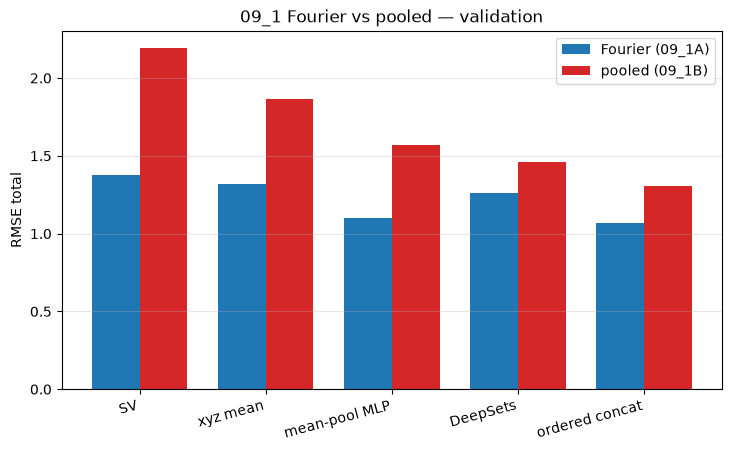

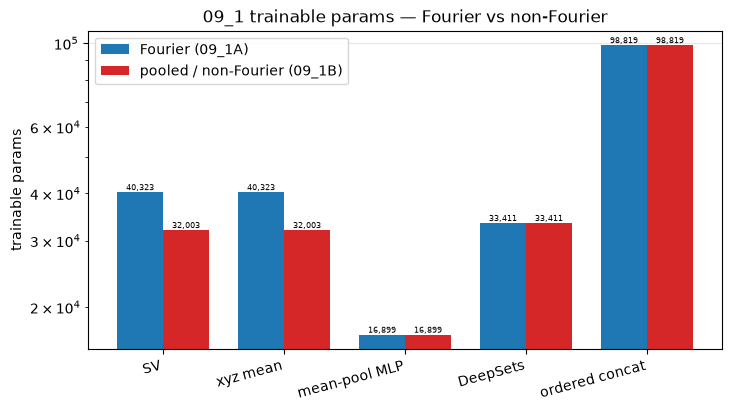

In [4]:
pooled = run_m9_frozen_fusion_family(
    M9FusionConfig(
        family="pooled",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        run_lr_study=cfg_paths["run_lr_study"],
        lr_stage_b_grid=DEFAULT_LR_STAGE_B_GRID,
        lr_stage_b_mean_pool=DEFAULT_LR_STAGE_B,
        lr_stage_b_ordered_concat=DEFAULT_LR_STAGE_B,
        lr_stage_b_deepsets=DEFAULT_LR_STAGE_B,
        load_existing=cfg_paths["load_existing"],
        retrain=cfg_paths["retrain"],
    )
)
display(pooled.comparison_df)
fig_lr = plot_m9_lr_study(pooled.lr_study_df, family="pooled", title="09_1B Stage-B LR (pooled)")
if fig_lr is not None:
    display(fig_lr)
display(plot_m9_rmse_ladder(pooled.comparison_df, family="pooled", title="09_1B pooled packing RMSE"))

fourier = run_m9_frozen_fusion_family(
    M9FusionConfig(
        family="fourier",
        workbook_path=cfg_paths["workbook_path"],
        data_root=cfg_paths["output_root"],
        results_dir=cfg_paths["results_dir"],
        stl_root=ROOT,
        device=device,
        num_epochs=cfg_paths["num_epochs"],
        early_stop_patience=cfg_paths["early_stop_patience"],
        angle_stride_deg=cfg_paths["angle_stride_deg"],
        run_lr_study=False,
        load_existing=True,
        retrain=False,
    )
)
fig_rmse = plot_m9_rmse_fourier_vs_pooled(
    fourier.comparison_df, pooled.comparison_df, split="validation"
)
if fig_rmse is not None:
    display(fig_rmse)
fig_params = plot_m9_param_counts_fourier_vs_pooled(
    fourier.comparison_df, pooled.comparison_df
)
if fig_params is not None:
    display(fig_params)


Interpretation is in Final Report M9 Step 1. Run `09_1A` first if Fourier artifacts are missing.
